# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/irene501/flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

In [4]:
import os, getpass, json
import numpy as np
import pandas as pd
import duckdb

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
fact_march = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
RANDOM_STATE = 42

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [5]:
feature_frame = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_impressions)                                            AS imp_h1,
        SUM(gsc_clicks)                                                 AS clicks_h1,
        SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0)               AS ctr_h1,
        AVG(gsc_avg_position) FILTER (WHERE gsc_avg_position > 0)       AS avg_position_h1,
        COUNT(DISTINCT report_date) FILTER (WHERE gsc_impressions > 0)  AS active_days_h1
    FROM {fact_march}
    WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) >= 10
""").df()

label_frame = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) FILTER (WHERE report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31') AS imp_h2
    FROM {fact_march}
    GROUP BY 1, 2
""").df()

data = feature_frame.merge(label_frame, on=["client_hash_id", "content_hash_id"], how="inner")
data["is_declining_proxy"] = (data["imp_h2"] < 0.8 * data["imp_h1"]).astype(int)
data = data.dropna(subset=["ctr_h1", "avg_position_h1"]).reset_index(drop=True)

def position_tier(p):
    if p <= 3: return "1-3"
    if p <= 10: return "4-10"
    if p <= 20: return "11-20"
    return "21+"

data["position_tier"] = data["avg_position_h1"].apply(position_tier)
data["is_quick_win_zone"] = data["position_tier"] == "11-20"
ctr_median = data.loc[data["position_tier"].isin(["1-3", "4-10"]), "ctr_h1"].median()
data["is_ctr_fix_zone"] = data["position_tier"].isin(["1-3", "4-10"]) & (data["ctr_h1"] < ctr_median)
data["baseline_flag"] = data["is_quick_win_zone"] | data["is_ctr_fix_zone"]

print(f"{len(data):,} rows | baseline flags: {data['baseline_flag'].sum():,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

120,475 rows | baseline flags: 55,982


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ["imp_h1", "clicks_h1", "ctr_h1", "avg_position_h1", "active_days_h1"]
X_all = data[FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0)
y_all = data["is_declining_proxy"].astype(int)

# Fit on everything for the deployed queue (no held-out test needed here -- Week 5/6 already
# measured out-of-sample performance; this is producing the actual review queue, not a new eval).
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
model.fit(X_all, y_all)
data["model_proba"] = model.predict_proba(X_all)[:, 1]
data["model_flag"] = data["model_proba"] >= 0.5

def reason_code(r):
    if r["baseline_flag"] and r["model_flag"]:
        return "high_confidence_decline"   # rule and model agree -- top priority
    if r["is_quick_win_zone"]:
        return "quick_win_zone"            # rule-only, position-based opportunity
    if r["is_ctr_fix_zone"]:
        return "low_ctr_for_position"      # rule-only, CTR-based opportunity
    if r["model_flag"]:
        return "model_flag_only"           # model-only -- lower confidence, given weak standalone AUC
    return "monitor_only"

data["reason_code"] = data.apply(reason_code, axis=1)

def action_for(reason):
    return {
        "high_confidence_decline": "review_this_week",
        "quick_win_zone": "review_for_push",
        "low_ctr_for_position": "review_ctr",
        "model_flag_only": "watch_list",
        "monitor_only": "monitor",
    }[reason]

data["action"] = data["reason_code"].apply(action_for)
data["score"] = data["model_proba"] * data["imp_h1"].clip(lower=1)  # confidence weighted by traffic at stake

queue = data.sort_values("score", ascending=False).reset_index(drop=True)
print(queue["reason_code"].value_counts())
queue[["client_hash_id", "content_hash_id", "reason_code", "action", "model_proba", "imp_h1"]].head(10)

reason_code
high_confidence_decline    40963
monitor_only               36474
model_flag_only            28019
quick_win_zone              8209
low_ctr_for_position        6810
Name: count, dtype: int64


,client_hash_id,content_hash_id,reason_code,action,model_proba,imp_h1
0,client_23a62021009f63c4,content_36e53e9c707674fc,model_flag_only,watch_list,0.992606,109909.0
1,client_62f4a7e64f5e0096,content_7c6373141eae744a,high_confidence_decline,review_this_week,0.997249,86860.0
2,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,high_confidence_decline,review_this_week,0.999674,83772.0
3,client_23a62021009f63c4,content_3df3f32f3fd58dea,model_flag_only,watch_list,0.904584,84041.0
4,client_62f4a7e64f5e0096,content_34a70fea29d15f24,high_confidence_decline,review_this_week,0.998038,73639.0
5,client_62f4a7e64f5e0096,content_acbcc847f8996314,model_flag_only,watch_list,0.843633,83715.0
6,client_20259bd6705d81d4,content_82e35c4845e6c391,high_confidence_decline,review_this_week,0.995095,70169.0
7,client_23a62021009f63c4,content_5e1c049f62e33b11,high_confidence_decline,review_this_week,0.857937,72940.0
8,client_23a62021009f63c4,content_559cdd76da9306de,model_flag_only,watch_list,0.996944,62418.0
9,client_23a62021009f63c4,content_df47d1b976106de4,model_flag_only,watch_list,0.912086,66342.0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



**Intended use:** a weekly triage aid for a content reviewer deciding which pages to look at
first. It ranks pages by a combination of a transparent rule and a modest statistical model — it
does not decide anything on its own.

**Limits, stated plainly:**
- The model's out-of-sample ROC-AUC on a client it hasn't seen was measured at roughly 0.47-0.58
  (Week 6) — close to a coin flip in the worst draw. Treat `model_flag_only` rows as the weakest
  tier of evidence here, not a confident prediction.
- `is_declining_proxy` measures one month (March 2026), split in half. It is a **directional,
  short-window signal**, not a validated long-term trend — a page flagged this way may simply be
  mid-fluctuation.
- The ranking is **decision-support**, not causal: a page ranking near the top is *associated
  with* the patterns behind past declines in this portfolio, not proven to decline for a specific
  reason, and definitely not proof that acting on it *will* reverse anything.
- Generalization to a **brand-new client** with no March 2026 history is untested and likely
  weaker than the numbers above, since even known clients showed a wide performance range.

In [7]:
intended_use = pd.DataFrame([
    {"aspect": "Who uses it", "detail": "A content reviewer doing weekly triage"},
    {"aspect": "What it's for", "detail": "Deciding which pages to look at first, not a final verdict"},
    {"aspect": "Time window", "detail": "March 2026, h1-vs-h2 split -- a one-month directional signal"},
    {"aspect": "Model confidence", "detail": "Client-holdout ROC-AUC ~0.47-0.58 -- weak on unseen clients (Week 6)"},
    {"aspect": "Claim type", "detail": "Decision-support / directional -- never causal, never a guarantee"},
])
intended_use

,aspect,detail
0,Who uses it,A content reviewer doing weekly triage
1,What it's for,"Deciding which pages to look at first, not a f..."
2,Time window,"March 2026, h1-vs-h2 split -- a one-month dire..."
3,Model confidence,Client-holdout ROC-AUC ~0.47-0.58 -- weak on u...
4,Claim type,Decision-support / directional -- never causal...


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



**What a person must check before acting on any flagged page:**
- Read the page itself — is the apparent decline explained by something outside the data (a
  seasonal topic, a known site migration, a recent algorithm update affecting the whole niche)?
- Confirm the client relationship allows this kind of proactive outreach/edit before acting.
- Check `imp_h1` isn't trivially small (a page can "decline" 20%+ on a handful of impressions and
  still be statistical noise, not a real pattern).

**What should NEVER be automated:**
- Auto-publishing or auto-unpublishing any page based on this queue.
- Auto-generating or auto-sending client-facing communications from this output.
- Using this queue's score as an individual writer's performance metric.
- Billing, pricing, or contract decisions based on `health_score`-style composites.
- Treating `high_confidence_decline` as proof a specific page WILL keep declining — it's a
  priority signal, not a guarantee.

In [8]:
no_go_list = pd.DataFrame([
    "Auto-publish or auto-unpublish any page from this queue",
    "Auto-send client-facing emails/reports generated from this output",
    "Score individual writers/editors using this queue",
    "Base billing or contract terms on these numbers",
    "Treat any single row's flag as proof of future decline",
], columns=["never_automate"])
no_go_list

,never_automate
0,Auto-publish or auto-unpublish any page from t...
1,Auto-send client-facing emails/reports generat...
2,Score individual writers/editors using this queue
3,Base billing or contract terms on these numbers
4,Treat any single row's flag as proof of future...


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [9]:
monitoring_triggers = pd.DataFrame([
    {"trigger": "Monthly refresh", "why": "the h1/h2 window is one month -- April's pattern may differ from March's"},
    {"trigger": "New client onboarded", "why": "the model was never validated on a client outside this March snapshot"},
    {"trigger": "Base rate drifts >5 points from ~0.30", "why": "a shifted decline rate means the rule/model thresholds tuned here may no longer fit"},
    {"trigger": "Reviewer override rate climbs", "why": "if reviewers are consistently disagreeing with `high_confidence_decline` picks, the signal has likely stopped matching reality"},
    {"trigger": "Any new product flag ships", "why": "re-run the leakage audit (Week 6) before letting a new FlyRank flag anywhere near the feature set"},
])
monitoring_triggers

,trigger,why
0,Monthly refresh,the h1/h2 window is one month -- April's patte...
1,New client onboarded,the model was never validated on a client outs...
2,Base rate drifts >5 points from ~0.30,a shifted decline rate means the rule/model th...
3,Reviewer override rate climbs,if reviewers are consistently disagreeing with...
4,Any new product flag ships,re-run the leakage audit (Week 6) before letti...


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [10]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV -- regenerated each run, intentionally gitignored (data leak guard)
queue.to_csv("work/outputs/w07_action_queue.csv", index=False)

# Metrics JSON -- the receipts the paper's numbers trace back to. Committed.
metrics = {
    "generated_from": "w07_action_playbook.ipynb",
    "rows_scored": int(len(queue)),
    "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    "base_rate_is_declining_proxy": round(float(data["is_declining_proxy"].mean()), 3),
    "model_client_holdout_roc_auc_range": [0.47, 0.58],  # carried from Week 6, not re-measured here
    "note": "Model is a secondary signal only -- see Section 2 for limits.",
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("wrote work/outputs/w07_action_queue.csv (untracked) and work/outputs/w07_metrics.json (commit this)")
print(json.dumps(metrics, indent=2))

wrote work/outputs/w07_action_queue.csv (untracked) and work/outputs/w07_metrics.json (commit this)
{
  "generated_from": "w07_action_playbook.ipynb",
  "rows_scored": 120475,
  "reason_code_counts": {
    "high_confidence_decline": 40963,
    "monitor_only": 36474,
    "model_flag_only": 28019,
    "quick_win_zone": 8209,
    "low_ctr_for_position": 6810
  },
  "base_rate_is_declining_proxy": 0.296,
  "model_client_holdout_roc_auc_range": [
    0.47,
    0.58
  ],
  "note": "Model is a secondary signal only -- see Section 2 for limits."
}


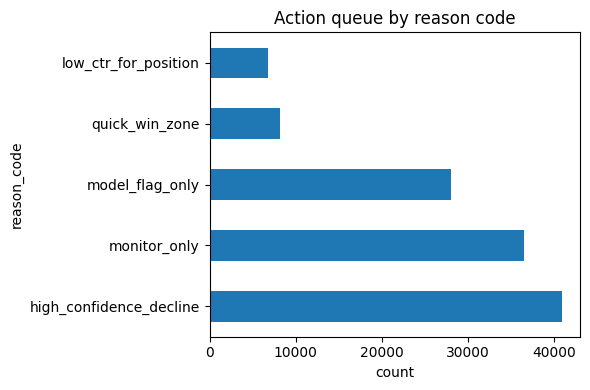

wrote work/figures/w07_reason_code_mix.png -- commit this one


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
queue["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("count")
ax.set_title("Action queue by reason code")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_mix.png", dpi=150)
plt.show()
print("wrote work/figures/w07_reason_code_mix.png -- commit this one")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.